**Evidence-coverage report: behavioural + PFC latent-dynamics diagnostic slice.**
This report evaluates the current report-backed evidence for HRM-style
working memory by inspecting behavioural prediction accuracy, PFC high-level
(`z_H`) and low-level (`z_L`) recurrent state dynamics, and halting/control
behaviour. The current evidence supports behavioural competence and a partial
latent-dynamics diagnostic slice, while working-memory content decoding,
causal intervention, and adaptive-computation analyses remain open.


| Field              | Value                                |
| ------------------ | ------------------------------------ |
| Model family       | HRM v1, HRM v2                       |
| Task               | Mazehard (iterative path prediction) |
| Created            | 2026-06-18T00:00:00Z                 |
| Device / precision | CPU (diagnostic regime)              |
| Seed               | Not recorded in provenance           |


Available reports and figures:


In [1]:
from ehc_sn.reporting import open_report
from IPython.display import Image, Markdown, display
from notebooks.utils import display_mermaid

# Report paths
HRM_V1_REPORT_PATH = "artifacts/reports/hrm_v1/mazehard_n1"
HRM_V2_REPORT_PATH = "artifacts/reports/hrm_v2/mazehard_n1"

# Load reports
hrm_v1_report = open_report(HRM_V1_REPORT_PATH)
hrm_v2_report = open_report(HRM_V2_REPORT_PATH)

# Display report summaries
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    s = report.summary()
    print(f"{label} report summary:")
    print(f"  - report:    {s['root']}")
    print(f"  - metrics:   {s['metric_count']}")
    print(f"  - figures:   {s['figure_count']}")
    print()

HRM v1 report summary:
  - report:    /home/borja/ehc-sn/artifacts/reports/hrm_v1/mazehard_n1
  - metrics:   7
  - figures:   6

HRM v2 report summary:
  - report:    /home/borja/ehc-sn/artifacts/reports/hrm_v2/mazehard_n1
  - metrics:   7
  - figures:   12



# Scientific Question

**Does the model maintain task-relevant information in its recurrent
working-memory states across deliberation steps, and do the high-level
and low-level PFC states exhibit distinct temporal dynamics consistent
with hierarchical reasoning?**

We inspect four dimensions to evaluate evidence at four levels:

| Level                      | Evidence required                                                |
| -------------------------- | ---------------------------------------------------------------- |
| **Behavioural**            | Does the model correctly predict the target path sequence?       |
| **Temporal dynamics**      | Do `z_H` and `z_L` evolve at different characteristic rates?     |
| **Working-memory content** | Is target-path information decodable from the recurrent state?   |
| **Computation control**    | Does the model adapt its halting behaviour to problem structure? |


# Task and Benchmark — Mazehard

Mazehard is a path-prediction task where the model receives a maze layout
as a grid of categorical token IDs and must predict which cells form the
optimal path from start to goal.

**Input**: A 2-D token grid encoding the maze topology — walls, free cells,
start position, and goal position. Each cell is represented by a discrete
token from a small vocabulary (typically 6 token types).

**Prediction task**: The model iteratively predicts a binary path overlay
mask over the grid positions designated as evaluation targets. At each
deliberation step the model produces a full-grid prediction; the task is
evaluated on whether the predicted path tokens match the ground-truth
target tokens at each position.

**Iterative refinement**: The HRM architecture performs multiple recurrent
passes (deliberation steps) over a fixed-size schema workspace. The model
can choose to halt early via an ACT-style halting policy (HRM v1) or
runs for a fixed episode budget (HRM v2). Predictions from the final
step (or the step at which halting occurred) are compared against the
ground-truth target overlay.

**Evaluation positions**: The supervised target is a subset of grid
positions — specifically those that lie on the optimal path. Background
positions are not scored.

Note that the model does not select actions in an environment. It receives
the full maze layout as input and iteratively refines its path prediction
through recurrent computation. This design isolates the working-memory
and deliberation mechanisms from action-selection confounds.


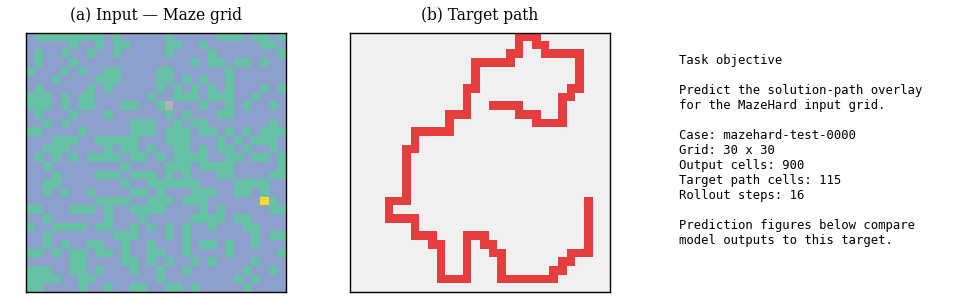

In [2]:
# Mazehard Task Overview (paradigm context; same dataset for both models)
overview_entry = hrm_v1_report.figure_entry(
    "mazehard_task_layout", preferred_format="png"
)
if overview_entry:
    abs_path = hrm_v1_report.root / overview_entry.path
    display(Image(filename=str(abs_path)))
else:
    print("mazehard_task_layout not available.")

> Figure 1: Example Mazehard task instance. Panel (a) shows the input token
> grid encoding the maze layout — walls, free cells, start, and goal positions.
> Panel (b) shows the ground-truth target path overlay. The model must predict
> which grid cells lie on the optimal path after iteratively refining its
> prediction through recurrent deliberation.


# Model Internals Inspected

The HRM architecture uses a two-level recurrent PFC (Prefrontal Cortex)
substrate: a high-level state that updates slowly to maintain abstract
planning context, and a low-level state that updates rapidly to perform
detailed token-level computation. Both states operate over a shared
schema workspace of token slots.

This report inspects the following internal variables and pathways.

| System             | Scientific role                        | Report-facing name         |
| ------------------ | -------------------------------------- | -------------------------- |
| PFC High (`z_H`)   | Slow abstract planning / subgoal state | PFC high-level state       |
| PFC Low (`z_L`)    | Fast detailed token computation        | PFC low-level state        |
| Schema workspace   | Structured working-memory token slots  | Schema-slot predictions    |
| Halting / Q-values | Computation control (termination)      | Halting signal / Q-values  |
| Output             | Behavioural path prediction            | Prediction argmax per step |
| Target             | Ground-truth path token sequence       | Target path overlay        |

## How the Two-Level Recurrence Works

HRM-based models maintain two coupled recurrent states that interact
at each deliberation step. Understanding their data flow is critical
for interpreting the latent dynamics diagnostics.


### The key variables

At each deliberation step, the model processes schema-slot tokens
through the two-level PFC recurrence:

- **Schema tokens** — the maze layout encoded as discrete token embeddings,
  placed into a fixed-size workspace of $N$ slots
- **High-level state `z_H`** — updated once per macro-step, provides
  abstract context to the low-level module
- **Low-level state `z_L`** — updated multiple times per macro-step,
  performs detailed token manipulation conditioned on `z_H`
- **Task head** — decodes the final workspace tokens into path predictions
- **Halting policy** (HRM v1) or **value head** (HRM v2) — determines
  when deliberation should terminate


### HRM v1 vs HRM v2

HRM v1 uses an ACT-style adaptive halting policy: at each step the model
outputs Q-logits over {halt, continue} actions and may stop early.
HRM v2 uses a fixed-budget episode with an actor-critic value head
that estimates state value for RL training but does not control
termination during diagnostic evaluation.


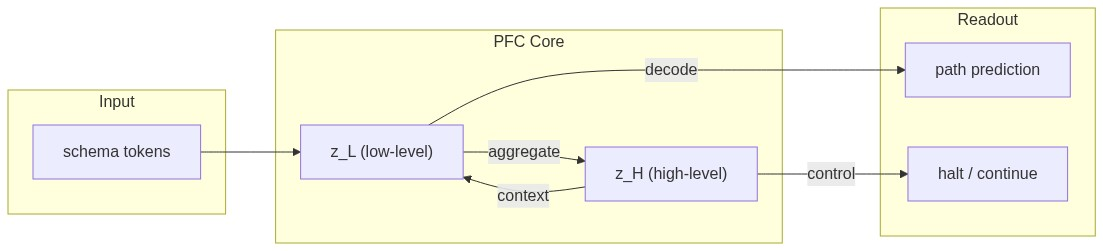

In [3]:
diagram = """
graph LR
    subgraph "Input"
        TOK["schema tokens"]
    end

    subgraph "PFC Core"
        ZH["z_H (high-level)"]
        ZL["z_L (low-level)"]
    end

    subgraph "Readout"
        PRED["path prediction"]
        HALT["halt / continue"]
    end

    TOK --> ZL
    ZH -->|"context"| ZL
    ZL -->|"aggregate"| ZH
    ZL -->|"decode"| PRED
    ZH -->|"control"| HALT
"""
display_mermaid(diagram)

### What the metrics measure — and what they don't

The primary Mazehard metrics are **token-level accuracy** and
**sequence-level exact match**. Token accuracy measures the fraction of
target-path positions where the model's predicted token matches ground
truth. Sequence exact match measures the fraction of full episodes where
every target position is correct.

These metrics establish behavioural competence — whether the model
solves the task — but they do not explain **how**. To understand the
role of working memory and hierarchical dynamics, we need to inspect
the latent states and control behaviour in the sections that follow.

**Chance baseline**: For a binary path/non-path classification with
strong class imbalance (most positions are background), a model that
always predicts the majority class achieves high token accuracy by
default. The meaningful baseline is therefore not random uniform but
the **majority-class classifier**, which the metrics should substantially
exceed.


# Behavioural Performance

The primary Mazehard metrics are token-level accuracy and sequence-level
exact match. Unlike Arena, Mazehard has a single prediction pathway
(the model iteratively refines one output) rather than three parallel
pathways. The key behavioural question is whether prediction quality
improves over deliberation steps.

| Metric                | Meaning                                                      |
| --------------------- | ------------------------------------------------------------ |
| **token_accuracy**    | Fraction of target-path positions predicted correctly        |
| **sequence_accuracy** | Mean token accuracy averaged over all sequences in the batch |
| **sequence_exact**    | Fraction of sequences where every target position is correct |
| **n_token_correct**   | Raw count of correctly predicted target-path positions       |
| **n_token_total**     | Total target-path positions evaluated                        |


In [4]:
# Display metrics from both HRM ReportRuns.
import pandas as pd

METRIC_KEYS = [
    "token_accuracy",
    "sequence_accuracy",
    "sequence_exact",
    "n_token_correct",
    "n_token_total",
]

reports = [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]

rows = []
for run_name, report in reports:
    for record in report.metrics():
        if record.metric in METRIC_KEYS:
            rows.append(
                {
                    "Run": run_name,
                    "Metric": record.metric,
                    "Value": record.value,
                    "Unit": record.unit,
                }
            )

table = pd.DataFrame(rows).set_index(["Run", "Metric"])
display(table)

Value   Unit
Run    Metric                              
HRM v1 token_accuracy       1.000000  ratio
       sequence_accuracy    1.000000  ratio
       sequence_exact       1.000000  ratio
       n_token_correct    900.000000  count
       n_token_total      900.000000  count
HRM v2 token_accuracy       0.515556  ratio
       sequence_accuracy    0.515556  ratio
       sequence_exact       0.000000  ratio
       n_token_correct    464.000000  count
       n_token_total      900.000000  count

> Table 1: Mazehard behavioural metrics for HRM v1 and HRM v2.
> `token_accuracy` is the **primary benchmark metric** for Mazehard.
> A value of 1.0 indicates perfect path prediction on the evaluated
> diagnostic cases.


Metric values are loaded dynamically from report artifacts. When a
metric is unavailable, the table shows the missing value explicitly
rather than treating the model as evaluated.

**Validity notes**: These metrics are from single-case diagnostic
evaluation runs (1 maze, 16 sequences). They demonstrate that the
checkpoint can solve the task but do not constitute a benchmark-grade
evaluation. Benchmark comparisons require multiple cases, multiple
seeds, and compatible dataset splits.


## Mazehard Prediction Evolution

The prediction evolution figure shows how the model's path prediction
develops across deliberation steps. At each step the model produces a
full-grid argmax prediction. Comparing early-step predictions against
later steps reveals whether the recurrent computation progressively
refines the output.

**What to look for**: Early steps may show noisy or incomplete path
predictions. If deliberation improves the output, later steps should
converge toward the ground-truth target path. The halting signal
(HRM v1) or the fixed step budget (HRM v2) determines which step's
prediction is treated as final.


HRM v1 — mazehard_prediction_evolution (case=mazehard_n1)


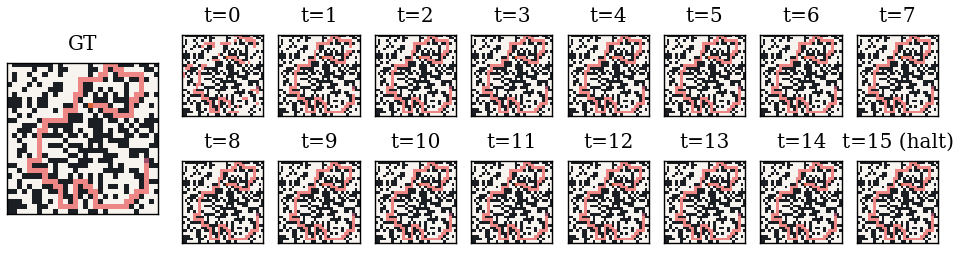

HRM v2 — mazehard_prediction_evolution (case=mazehard_n1)


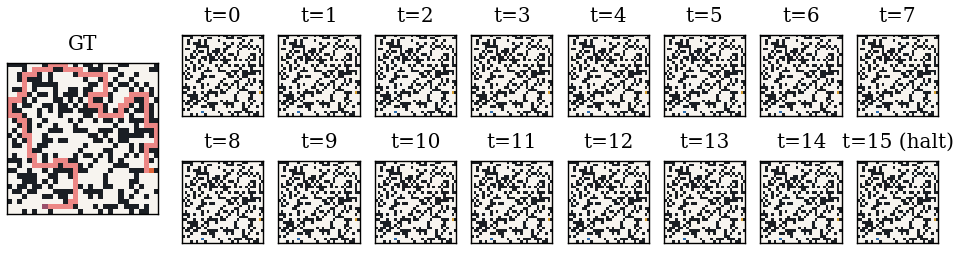

In [5]:
# --- Mazehard prediction evolution: first case from each ReportRun ---
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("mazehard_prediction_evolution", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mazehard_prediction_evolution not available.")

> Figure 2: Prediction evolution for the first case in each ReportRun.
> Each panel shows the model's argmax path prediction at successive
> deliberation steps compared to the ground-truth (GT) target path.
> Early steps may show partial or incorrect predictions; convergence
> toward GT in later steps indicates that recurrent deliberation
> progressively refines the output.


HRM v1 — prediction_accuracy_over_steps (case=mazehard_n1)


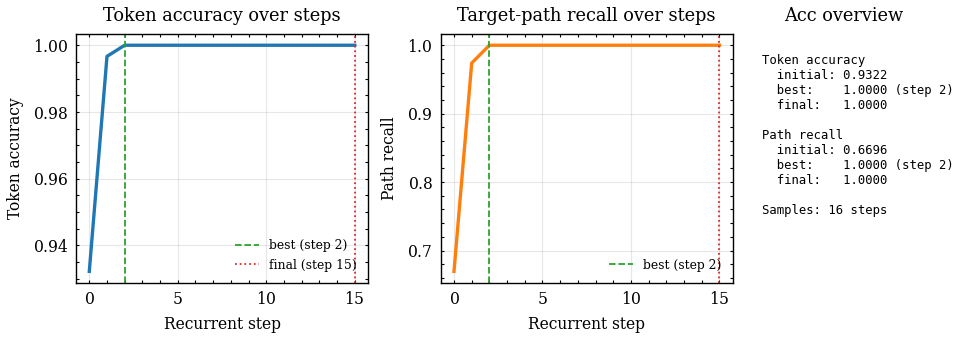

HRM v2 — prediction_accuracy_over_steps (case=mazehard_n1)


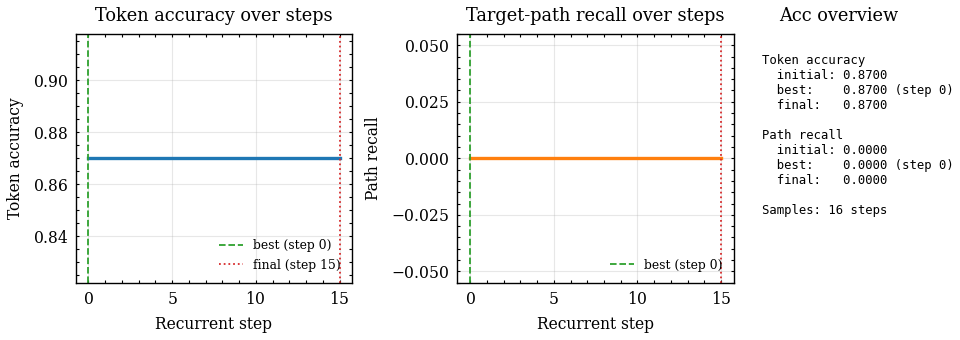

In [6]:
# --- Prediction accuracy over steps ---
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry(
        "prediction_accuracy_over_steps", preferred_format="png"
    )
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: prediction_accuracy_over_steps not available.")

> Figure 3: Prediction accuracy and target-path recall over recurrent
> rollout steps. Per-step token accuracy and sequence-level completion
> metrics show whether prediction quality improves monotonically with
> additional deliberation or plateaus early.


# PFC Hierarchical Recurrent Dynamics

The HRM architecture's defining feature is the coupled two-level recurrence:
a high-level state `z_H` that updates slowly, providing stable abstract
context, and a low-level state `z_L` that updates rapidly, performing
detailed token-level computation. This section evaluates whether the
two states exhibit distinct temporal dynamics consistent with hierarchical
reasoning.

We inspect two diagnostic figures:

- **pfc_latent_dynamics**: State magnitude (L2 norm) and update magnitude
  (L2 delta) for both `z_H` and `z_L` over rollout steps. Tests whether
  the states evolve and whether their update rates differ.
- **h_l_residuals_over_steps**: Forward residuals, cosine similarity between
  consecutive steps, and H/L residual separation ratio. Provides a
  finer-grained view of state convergence.

### Variables inspected

- `pfc/z_H`: High-level state, shape `(T, B, S, D)` — time × batch × slots × hidden
- `pfc/z_L`: Low-level state, shape `(T, B, S, D)` — same shape as `z_H`
- `t`: Deliberation step index (horizontal axis in all panels)

**Important**: These figures require `pfc/z_H` and `pfc/z_L` traces in
the evaluation artifacts. If these traces were not collected during
evaluation (see the evaluation CLI `--trace-keys` flag), the figures
will not be available. The notebook reports their status explicitly.


## Latent State Dynamics

**What to look for**: Three properties. First, whether `z_H` and `z_L`
norms diverge or track each other — divergent norms suggest the states
encode different information. Second, whether the per-step update
magnitude (delta) of `z_H` is consistently smaller than that of `z_L` —
this would indicate that the high-level state changes more slowly,
consistent with slower-timescale abstract planning. Third, whether
both states converge (diminishing deltas) or continue to change
throughout the episode — convergence suggests the deliberation reaches
a fixed point.


HRM v1: pfc_latent_dynamics not available — evaluation artifact may lack pfc/z_H and pfc/z_L traces.
HRM v2 — pfc_latent_dynamics (case=mazehard_n1)


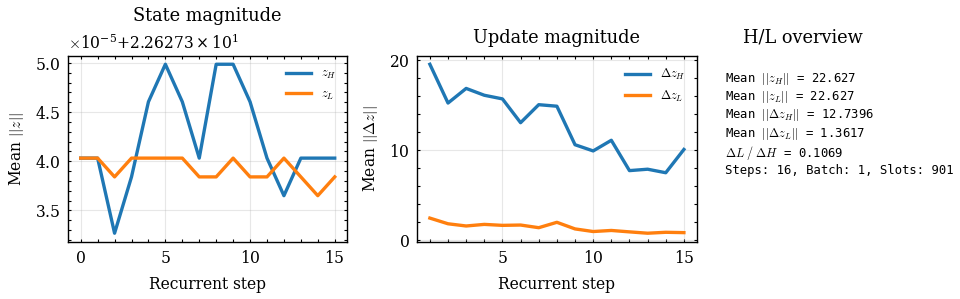

In [7]:
# --- PFC latent dynamics: first case from each ReportRun ---
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("pfc_latent_dynamics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(
            f"{label}: pfc_latent_dynamics not available — "
            f"evaluation artifact may lack pfc/z_H and pfc/z_L traces."
        )

> Figure 4: PFC latent dynamics overview. Panel (a) shows the L2 norm
> of `z_H` (blue) and `z_L` (orange) over deliberation steps. Panel (b)
> shows the per-step update magnitude (L2 delta). Panel (c) shows
> summary scalar metrics. A consistent gap between H and L delta
> magnitudes would support hierarchical timescale separation.

**Interpretation guide**. Panel (a): If both states maintain similar
norms throughout the episode, they may encode information at comparable
strength. Divergent norms suggest differential information content.
Panel (b): A smaller `z_H` delta than `z_L` delta supports the
hypothesis that the high-level state changes more slowly (stable
planning context) while the low-level state performs rapid computation.
Panel (c): The `h_l_delta_ratio` below 1.0 indicates that `z_H` changes
more slowly than `z_L` on average.

The main limitation is that these diagnostics are purely descriptive —
they measure state change magnitude, not whether the change is
task-relevant or causally necessary. Causal claims require ablation
or intervention experiments not yet implemented.


## H/L Residual Dynamics

This figure provides a finer-grained view of state convergence.
Panel (a) shows forward residuals `||z[t] - z[t-1]||` — how much each
state changes between consecutive steps. Panel (b) shows cosine
similarity between consecutive states — values near 1.0 indicate the
state has stabilised. Panel (c) shows the H/L residual separation
ratio.

**What to look for**: Forward residuals should decrease if the
deliberation converges. Cosine similarity should increase toward 1.0.
The separation ratio should be consistent with the timescale hypothesis
(H updating more slowly than L).


HRM v1: h_l_residuals_over_steps not available — evaluation artifact may lack pfc/z_H and pfc/z_L traces.
HRM v2 — h_l_residuals_over_steps (case=mazehard_n1)


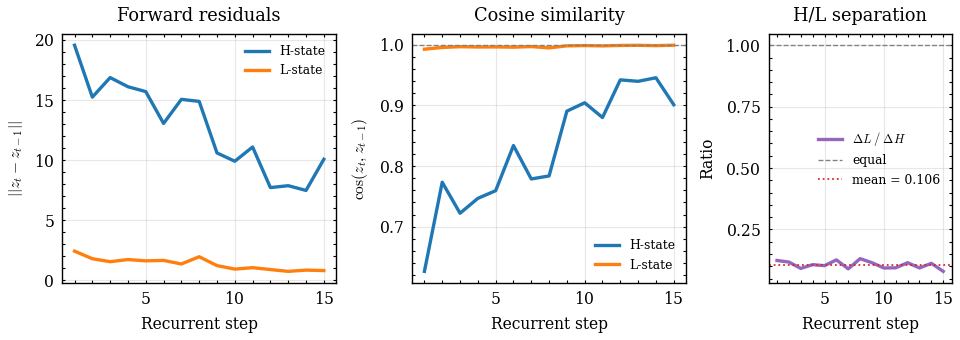

In [8]:
# --- H/L residuals over steps ---
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("h_l_residuals_over_steps", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(
            f"{label}: h_l_residuals_over_steps not available — "
            f"evaluation artifact may lack pfc/z_H and pfc/z_L traces."
        )

> Figure 5: H/L residual dynamics. Panel (a): forward residuals
> `||z[t] - z[t-1]||`. Panel (b): consecutive-step cosine similarity.
> Panel (c): H/L residual separation ratio. Decreasing residuals and
> increasing similarity indicate state convergence.

**Section conclusion — PFC dynamics**. These diagnostics describe whether
the recurrent states change over time and whether their update rates
differ. They do not establish that the observed dynamics are causally
necessary for task performance, nor do they establish that the states
encode task-relevant information. Those claims require the decoding and
intervention diagnostics discussed in the following sections.


# Working-Memory Content

The PFC latent dynamics figures show **that** the states change. This
section asks **what** they represent.

## Path Memory Probe

The `pfc_path_memory_probe` uses linear decoding (logistic regression
with stratified cross-validation) to test whether target-path information
can be read out from `z_H` and `z_L` at each deliberation step.

**What it tests**: Can a simple linear classifier, trained on the
recurrent state at step `t`, predict which grid positions belong to
the target path? Above-chance decoding accuracy indicates that
path-relevant information is **represented** in the state.

**What it does NOT test**: Whether the model **uses** this information
to produce its predictions. Decoding establishes availability, not
causal use. Causal claims require ablation, state corruption, or
intervention experiments.

> **Status**: The `pfc_path_memory_probe` requires a separate probe
> evaluation run that has not yet been executed against the current
> HRM checkpoints. Until this probe evaluation is completed, the
> question of whether path information is decodable from the recurrent
> state remains **untested**. The probe infrastructure exists in
> `src/ehc_sn/eval/probes/working_memory.py` and can be run via
> `compute_and_persist_probes_for_artifact()`.

### Variables inspected (when available)

- `pfc/z_H`: High-level state at each step, shape `(T, B, S, D)`
- `pfc/z_L`: Low-level state at each step, same shape
- `target/solution_overlay`: Ground-truth binary path mask, shape `(B, N)`
- Probe method: Logistic regression with balanced class weights, 5-fold stratified CV
- Metrics: Balanced accuracy, ROC AUC, Average Precision — per step, per state


# Computation Control and Halting

HRM v1 and HRM v2 use different mechanisms to control how many
deliberation steps are executed:

- **HRM v1 (ACT-style)**: At each step the model emits Q-logits over
  {halt, continue} actions. The halting policy may terminate
  deliberation early. The `halt_logit_evolution` figure shows how
  these logits evolve over steps.
- **HRM v2 (fixed-budget RL)**: The model runs for a fixed episode
  horizon. A value head estimates state value for RL training but
  does not control termination during diagnostic evaluation.

## Halting Timeline

The `halting_timeline` figure shows a binary heatmap of the halting
signal over rollout steps. It requires only the `act/halted` trace,
which is present in the current evaluation artifacts.

**What to look for**: Whether halting occurs at consistent steps
across sequences, or adapts to problem difficulty. Early halting
on simple cases and later halting on hard cases would indicate
adaptive computation allocation.


In [9]:
# --- Halting timeline ---
for label, report in [("HRM v1", hrm_v1_report), ("HRM v2", hrm_v2_report)]:
    entry = report.figure_entry("halting_timeline", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: halting_timeline not available.")

HRM v1: halting_timeline not available.
HRM v2: halting_timeline not available.


> Figure 6: Halting timeline. Binary heatmap showing which sequences
> have halted at each step. In HRM v1, halting is controlled by the
> ACT policy. In HRM v2, all sequences run for the fixed episode budget.


# Evidence Ledger

The following table summarises which claims about HRM working memory
and deliberation are supported by the current report artifacts, which
remain untested, and which require upstream evaluation or probe work.

| Question                                                | Status     | Evidence                                            |
| ------------------------------------------------------- | ---------- | --------------------------------------------------- |
| Does the model solve Mazehard?                          | Supported  | `token_accuracy`, `sequence_exact` in metrics       |
| Does deliberation improve predictions?                  | Supported  | `prediction_accuracy_over_steps` figure             |
| Do `z_H` and `z_L` evolve at different timescales?      | Untested\* | Requires `pfc/z_H`, `pfc/z_L` traces in eval        |
| Is task-relevant information decodable from the states? | Untested   | Requires probe evaluation (`pfc_path_memory_probe`) |
| Does halting adapt to problem difficulty?               | Untested\* | Requires `halting_timeline` figure in report        |
| Is the hierarchical recurrence causally necessary?      | Untested   | Requires ablation or state-intervention experiments |

\* Figure infrastructure exists but evaluation artifacts may lack the
required trace data. Re-running evaluation with extended `--trace-keys`
will populate these diagnostics.


## Limitations

The evidence presented in this notebook is **correlational and descriptive**.
The latent dynamics figures show that states change and may change at
different rates; they do not establish that the observed dynamics cause
the observed behaviour. The path memory probe, when executed, will show
whether information is **available** in the recurrent state, not whether
it is **used**. Causal claims about working memory require intervention
experiments (state ablation, structured corruption, or gradient-based
attribution) that are not yet implemented in the evaluation pipeline.
